In [134]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

## Questão 7 - Previsão de demanda

**Cenário**

O Sr. Almir está furioso. No último verão, o estoque de "Coletes Salva-Vidas" acabou em 10 dias, e a empresa perdeu milhares de reais em vendas. Por outro lado, compraram "Âncoras" demais e elas estão enferrujando no galpão. Gabriel Santos, o Tech Lead, disse que não dá mais para confiar no "feeling". Ele quer um modelo preditivo que diga exatamente quantas unidades venderemos no próximo mês para ajustar as compras com fornecedores.



**Premissas obrigatórias:**
- O período de treino deve incluir dados até 31/12/2023.
- O período de teste deve ser todo o mês de Janeiro de 2024.
- A previsão deve ser feita em base diária.
- Não é permitido utilizar dados futuros no treino (data leakage).
-  apenas o produto: "Motor de Popa Yamaha Evo Dash 155HP"

**Tarefa:**
1. Utilize o dataset vendas_2023_2024.csv
2. Construa um modelo baseline simples, utilizando: Média móvel dos últimos 7 dias de vendas (considerando apenas dados anteriores à data prevista).
3. Gere a previsão diária de vendas para Janeiro de 2024.
4. Compare as previsões com os valores reais do período de teste utilizando a métrica: MAE — Mean Absolute Error
5. Responda objetivamente:
     a. O baseline é adequado para esse produto?
     b. Cite uma limitação desse método.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [27]:
# Trazendo a planilha de vendas

df_vendas = pd.read_csv("raw_data/vendas_2023_2024.csv")

# Corrigindo a coluna de datas

df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], dayfirst=True, format='mixed')

In [28]:
# Filtrando para o produto "Motor de Popa Yamaha Evo Dash 155HP" (id = 54)
df_prod = df_vendas[df_vendas['id_product'] == 54]

In [29]:
df_prod

,id,id_client,id_product,qtd,total,sale_date
46,48,13,54,15,1823022.00,2024-05-30
53,55,35,54,3,346373.80,2024-11-24
71,74,45,54,11,1270038.85,2024-09-25
442,451,42,54,13,1500955.35,2024-02-19
494,503,45,54,11,1270038.85,2024-11-27
...,...,...,...,...,...,...
9210,9308,20,54,2,230916.50,2024-06-25
9365,9464,20,54,12,1385497.10,2024-05-27
9426,9526,37,54,15,1731870.90,2023-02-27
9508,9609,19,54,13,1500955.35,2023-05-16


In [30]:
# Criando série diária - Preenche com 0 os dias sem venda do produto em questão

df_prod_diario = (
    df_prod
    .groupby('sale_date')['qtd']
    .sum()
)

# Criar índice completo de datas
full_index = pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')

# Reindexar para ter todos os dias
df_prod_diario = df_prod_diario.reindex(full_index, fill_value=0)

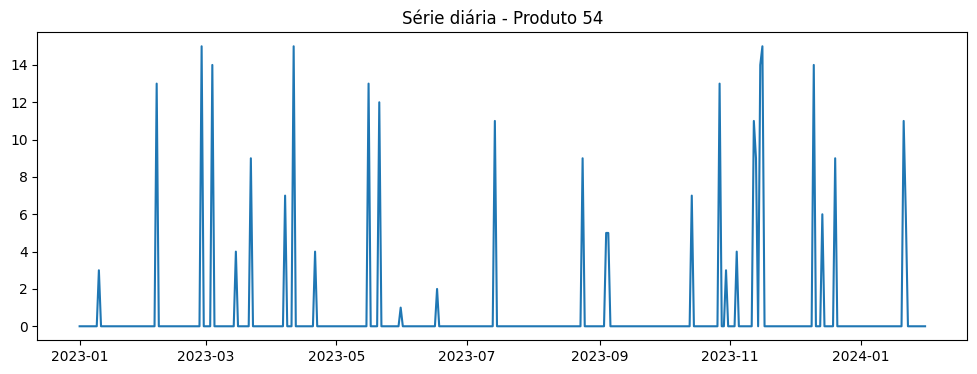

In [31]:
plt.figure(figsize=(12,4))
plt.plot(df_prod_diario)
plt.title('Série diária - Produto 54')
plt.show()

In [32]:
# Criando dataframe final

df_prod_final = (
    df_prod_diario
    .reindex(full_index, fill_value=0)
    .to_frame(name='qtd_real')
    .rename_axis('data')
    .reset_index()
)

df_prod_final

,data,qtd_real
0,2023-01-01,0
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
...,...,...
391,2024-01-27,0
392,2024-01-28,0
393,2024-01-29,0
394,2024-01-30,0


In [33]:
# Modelo de Previsão com Média Móvel de 7 dias

# Extipulando datas de treino e de teste

train = df_prod_diario[:'2023-12-31']
test = df_prod_diario['2024-01-01':'2024-01-31']

predictions = []

# histórico começa com dados reais
history = list(train)

for i in range(len(test)):
    
    # média dos últimos 7 dias
    if len(history) < 7:
        yhat = np.mean(history)
    else:
        yhat = np.mean(history[-7:])
    
    predictions.append(yhat)

    history.append(test.iloc[i])

In [36]:
# Dataframe de resultados
df_janeiro2024 = df_prod_final[df_prod_final['data'] >= '2024-01-01'].copy()
df_janeiro2024['previsao'] = predictions

# Cállculo do MAE
mae = mean_absolute_error(df_janeiro2024['qtd_real'], df_janeiro2024['previsao'])

# Soma da primeira semana
soma_semana = df_janeiro2024[df_janeiro2024['data'] <= '2024-01-07']['previsao'].sum()

# Resultados
print(df_janeiro2024[['data', 'qtd_real', 'previsao']].to_string())
print(f"\nMAE: {mae:.4f}")
print(f"\nSoma prevista primeira semana: {round(soma_semana)}")

          data  qtd_real  previsao
365 2024-01-01         0  0.000000
366 2024-01-02         0  0.000000
367 2024-01-03         0  0.000000
368 2024-01-04         0  0.000000
369 2024-01-05         0  0.000000
370 2024-01-06         0  0.000000
371 2024-01-07         0  0.000000
372 2024-01-08         0  0.000000
373 2024-01-09         0  0.000000
374 2024-01-10         0  0.000000
375 2024-01-11         0  0.000000
376 2024-01-12         0  0.000000
377 2024-01-13         0  0.000000
378 2024-01-14         0  0.000000
379 2024-01-15         0  0.000000
380 2024-01-16         0  0.000000
381 2024-01-17         0  0.000000
382 2024-01-18         0  0.000000
383 2024-01-19         0  0.000000
384 2024-01-20         0  0.000000
385 2024-01-21        11  0.000000
386 2024-01-22         6  1.571429
387 2024-01-23         0  2.428571
388 2024-01-24         0  2.428571
389 2024-01-25         0  2.428571
390 2024-01-26         0  2.428571
391 2024-01-27         0  2.428571
392 2024-01-28      